# Estigmatismo y aplanatismo — lentes ovoides de superficies de Descartes

Un óvalo de Descartes es rigurosamente estigmático para *un* par de conjugados.
Encadenar N de ellos — la imagen de cada superficie es el objeto de la siguiente —
produce una **lente ovoide estigmática** (SOL): cero aberración esférica a cualquier
apertura, sin aproximación paraxial. Las conjugadas intermedias quedan libres, y esa
libertad compra la segunda propiedad: el **aplanatismo** (condición del seno de Abbe,
que elimina el coma), con la condición cerrada de Silva-Lora & Torres.

Este notebook verifica cada afirmación sobre rayos trazados exactos:

1. tres singletes con los mismos conjugados y curvaturas de vértice — esférico,
   estigmático y aplanático — y sus spots axiales;
2. el mapa de aplanatismo $M$ (Ec. 25 del artículo) contra el cociente de senos real;
3. la **superficie donde se forma la imagen aplanática** y el crecimiento del blur
   (lineal = coma, cuadrático = sin coma);
4. los SOL del artículo: triplete cementado de 4 superficies (optimización en vivo) y
   triplete en aire de 6 superficies con **campo plano**;
5. **mallas de distorsión** de los tres sistemas nuevos;
6. abanicos de rayos, métricas de campo y coeficientes de Seidel.

**Fuentes.** A. Silva-Lora y R. Torres, *Aplanatism in stigmatic optical systems*,
J. Opt. Soc. Am. A 37 (2020); *Superconical aplanatic ovoid singlet lenses*,
J. Opt. Soc. Am. A 37, 1155–1165 (2020); *Explicit Cartesian oval as a superconic
surface…*, Proc. R. Soc. A 476, 20190894 (2020).

In [1]:
import warnings

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from raytracer.design import OpticalSystem, StigmaticTrain, SurfaceRow
from raytracer.optics.materials import AIR, ConstantIndex
from raytracer.optimize import optimize_aplanat
from raytracer.propagation import (
    FieldPoint, PupilSampling, SequentialTracer, trace_from_object, trace_pupil,
)
from raytracer.analysis import (
    aplanatic_image_surface, aplanatism_report, distortion_grid, field_metrics,
    ray_fans, seidel_coefficients, spot_data,
)
from raytracer.viz import plots
from raytracer.viz.bodies import draw_system

warnings.filterwarnings("ignore", category=RuntimeWarning)
np.set_printoptions(precision=4, suppress=False, linewidth=120)
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})

## 1. Tres singletes, mismos conjugados, mismas curvaturas de vértice

Conjugados $-30 \to +70$ mm, espesor 40 mm, $n = 1{,}5$, NA objeto 0,08. El
**aplanático** es el singlete Omega simétrico: conjugada intermedia en el centro de la
lente (un foco real dentro del vidrio), imagen en $\xi - d_0$, de modo que la segunda
superficie es la primera reflejada. El **estigmático** mueve solo la conjugada
intermedia ($d_1 = 300$). La **esfera** copia las curvaturas de vértice del aplanático,
así que es el mismo sistema paraxial.

In [2]:
N_GLASS, D0, D2, THICKNESS = 1.5, -30.0, 70.0, 40.0
SEMI, NA = 3.5, 0.08

aplanat = StigmaticTrain.symmetric_singlet(
    n=N_GLASS, d0=D0, thickness=THICKNESS, semidiameter=SEMI)
stigmatic = StigmaticTrain.singlet(
    n=N_GLASS, d0=D0, d1=300.0, d2=D2, thickness=THICKNESS, semidiameter=SEMI)

radius = 1.0 / aplanat.profiles[0].curvature
glass = ConstantIndex(f"N{N_GLASS}", N_GLASS)
sphere = OpticalSystem(
    [SurfaceRow.refracting(radius=radius, thickness=THICKNESS, material=glass, semidiameter=SEMI),
     SurfaceRow.refracting(radius=-radius, thickness=D2 - THICKNESS, material=AIR, semidiameter=SEMI)],
    object_space=AIR, object_z=D0,
)

print(f"radio de vértice compartido: R = ±{radius:.4f} mm")
print(f"conjugadas del aplanático:  {aplanat.conjugates}   gt = {aplanat.gt:+.1f}")
print(f"conjugadas del estigmático: {stigmatic.conjugates}   gt = {stigmatic.gt:+.4f}")

def axial_rms_um(system):
    pupil = trace_pupil(SequentialTracer(system), FieldPoint(y=0.0), na_object_sine=NA,
                        sampling=PupilSampling(kind="rings", radial=10, azimuth=48),
                        chief_slope=0.0)
    return spot_data(pupil).rms_radius_um

print(f"\nspot axial RMS  esfera:      {axial_rms_um(sphere):12.1f} µm")
print(f"spot axial RMS  estigmático: {axial_rms_um(stigmatic.to_system()):12.3e} µm")
print(f"spot axial RMS  aplanático:  {axial_rms_um(aplanat.to_system()):12.3e} µm")

radio de vértice compartido: R = ±4.6154 mm
conjugadas del aplanático:  (-30.0, 20.0, 70.0)   gt = +1.0
conjugadas del estigmático: (-30.0, 300.0, 70.0)   gt = -1.1538

spot axial RMS  esfera:            3864.8 µm
spot axial RMS  estigmático:    1.296e-12 µm
spot axial RMS  aplanático:     2.211e-12 µm


Doce órdenes de magnitud entre la esfera y cualquiera de los dos trenes de
Descartes: el estigmatismo es exacto, y el residuo es el suelo de la doble precisión.

## 2. El mapa de aplanatismo $M$

Por cada superficie, la normal en el punto de impacto cruza el eje a $V_kC_k$ del
vértice (Ec. 24, forma cerrada en los parámetros GOTS). El cociente de senos factoriza
como $\sin u_0/\sin u_N = (n_N/n_0)\, g_t\, M$, con $M = 1$ paraxial siempre; el
sistema es aplanático exactamente cuando $M \equiv 1$ para **todo** rayo. El reporte
traza un abanico meridional real, evalúa $M$ en los impactos trazados, y contrasta la
forma cerrada contra el cociente de senos medido — las dos rutas deben coincidir.

estigmático (d1 = 300)   (M-1)_RMS = 2.477e-03   gt = -1.153846   |forma cerrada - trazado| < 8.9e-16


aplanático (simétrico)   (M-1)_RMS = 1.773e-16   gt = +1.000000   |forma cerrada - trazado| < 4.4e-15


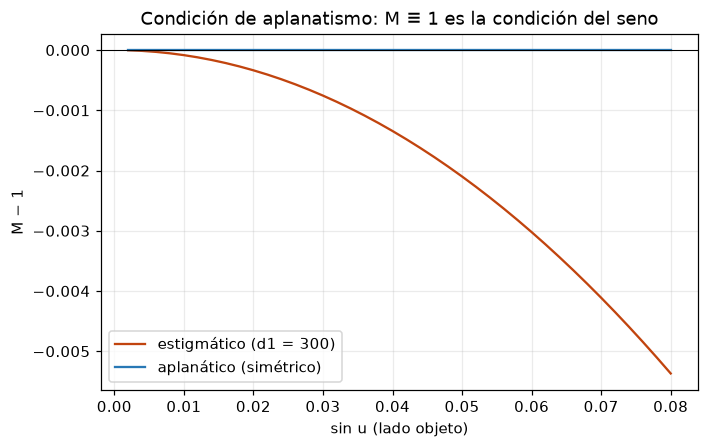

In [3]:
fig, ax = plt.subplots(figsize=(7, 4.2))
for name, train, color in [("estigmático (d1 = 300)", stigmatic, "#c1440e"),
                           ("aplanático (simétrico)", aplanat, "#2878b5")]:
    report = aplanatism_report(train, na_object_sine=NA, samples=40)
    ax.plot(report.sines_object[report.valid], report.map_values[report.valid] - 1.0,
            color=color, label=name)
    print(f"{name:24s} (M-1)_RMS = {report.map_rms:9.3e}   gt = {report.gt:+.6f}   "
          f"|forma cerrada - trazado| < {np.nanmax(np.abs(report.formula_residual[report.valid])):.1e}")
ax.axhline(0.0, color="black", lw=0.7)
ax.set(xlabel="sin u (lado objeto)", ylabel="M − 1",
       title="Condición de aplanatismo: M ≡ 1 es la condición del seno")
ax.legend(); ax.grid(alpha=0.25)
plt.show()

El simétrico deja $M - 1$ en 2×10⁻¹⁶ — aplanático **exacto**, por simetría
especular cada rayo sale con el seno con que entró. Y en ambos sistemas la forma
cerrada del artículo coincide con el cociente de senos de los rayos exactos a ~10⁻¹⁵
por rayo: la fórmula y el trazador se avalan mutuamente.

## 3. La superficie imagen aplanática y el crecimiento del blur

Para cada altura de objeto se traza un cono y el haz emergente se reduce a su punto de
convergencia por mínimos cuadrados. El lugar de esos puntos es la línea discontinua de
las figuras del artículo: **donde se forma la imagen aplanática**. El blur en ese
punto crece *lineal* con el campo si hay coma, *cuadrático* si no lo hay.

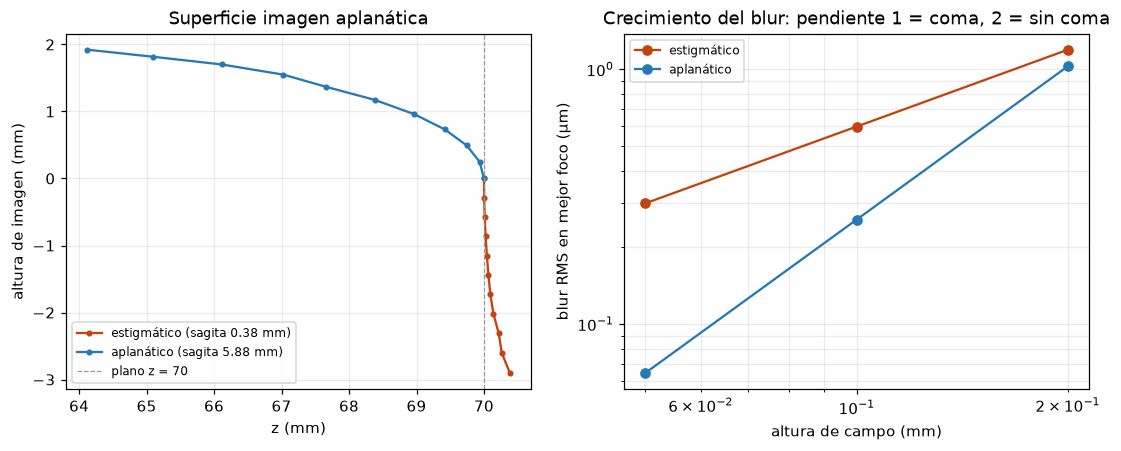

estigmático  blur(0.1)/blur(0.05) = 2.00   blur(0.2)/blur(0.1) = 2.00
aplanático   blur(0.1)/blur(0.05) = 4.00   blur(0.2)/blur(0.1) = 4.00


In [4]:
heights_locus = np.linspace(0.0, 2.5, 11)
fields_blur = np.array([0.0, 0.05, 0.1, 0.2])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
blur = {}
for name, train, color in [("estigmático", stigmatic, "#c1440e"),
                           ("aplanático", aplanat, "#2878b5")]:
    locus = aplanatic_image_surface(train, heights_locus, na_object_sine=NA)
    axes[0].plot(locus.points[:, 2], locus.points[:, 1], "o-", ms=3, color=color,
                 label=f"{name} (sagita {locus.max_sagitta:.2f} mm)")
    blur[name] = aplanatic_image_surface(train, fields_blur, na_object_sine=NA).blur_rms_um
axes[0].axvline(D2, color="#999999", ls="--", lw=0.8, label=f"plano z = {D2:g}")
axes[0].set(xlabel="z (mm)", ylabel="altura de imagen (mm)",
            title="Superficie imagen aplanática")
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.25)

for name, color in [("estigmático", "#c1440e"), ("aplanático", "#2878b5")]:
    axes[1].loglog(fields_blur[1:], blur[name][1:], "o-", color=color, label=name)
axes[1].set(xlabel="altura de campo (mm)", ylabel="blur RMS en mejor foco (µm)",
            title="Crecimiento del blur: pendiente 1 = coma, 2 = sin coma")
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.25, which="both")
plt.show()

for name in blur:
    b = blur[name]
    print(f"{name:12s} blur(0.1)/blur(0.05) = {b[2]/b[1]:.2f}   blur(0.2)/blur(0.1) = {b[3]/b[2]:.2f}")

Cocientes 2,00 y 4,00 exactos al duplicar el campo: el coma se fue del
aplanático y queda astigmatismo. Nótese la contrapartida: la superficie imagen del
aplanático exacto está fuertemente **curvada** — el aplanatismo no aplana el campo.

## 4. Los SOL del artículo: 4 superficies, y campo plano con 6

El triplete cementado de la Fig. 3a del artículo ($\zeta = 0, 15, 25, 35$;
$n$ = 1 / 1,517122 / 1,670591 / 1,851280 / 1; conjugados $-100 \to +90$). La familia
entera es estigmática; `optimize_aplanat` gasta las tres conjugadas intermedias en
anular $M - 1$ sobre la apertura — la metodología del artículo con `least_squares` en
lugar de búsqueda aleatoria.

In [5]:
CEMENTED = dict(media=(1.0, 1.517122, 1.670591, 1.851280, 1.0),
                vertices=(0.0, 15.0, 25.0, 35.0), semidiameter=10.0)

start = StigmaticTrain(conjugates=(-100.0, -150.0, -600.0, 450.0, 90.0), **CEMENTED)
fit = optimize_aplanat(start, na_object_sine=0.195, samples=21,
                       bounds=(-3000, 3000), diff_step=1e-4,
                       xtol=1e-14, ftol=1e-14, gtol=1e-14)
cemented = fit.train
print(fit.summary())

free conjugates: 3  ->  d = (-121.0933, -618.8219, 418.6358)
(M - 1) RMS: 0.00313  ->  3.13e-06
gt: -0.503855  ->  -0.494337


Con peso de campo plano (`flat_field_weight`) el residual se amplía con la
sagita de la superficie imagen. Tres grados de libertad (N=4) compran aplanatismo *o*
campo plano; cinco (N=6, triplete en aire de la Fig. 3b: $\zeta = 0,15,25,35,45,65$,
vidrio 1,516798, conjugados $-100 \to +120$) compran los dos. La búsqueda multiarranque
tarda ~2 min (`RERUN_FLAT_FIELD = True` la relanza); aquí partimos de su óptimo y lo
re-pulimos en segundos, verificándolo en vivo.

In [6]:
AIR_SPACED = dict(media=(1.0, 1.516798, 1.0, 1.516798, 1.0, 1.516798, 1.0),
                  vertices=(0.0, 15.0, 25.0, 35.0, 45.0, 65.0), semidiameter=10.0)
FIELDS_FLAT = [0.0, 1.0, 2.0, 3.0]
RERUN_FLAT_FIELD = False

if RERUN_FLAT_FIELD:
    rng = np.random.default_rng(11)
    best = None
    for _ in range(4):
        d = rng.uniform(-900, 900, size=5)
        try:
            trial = optimize_aplanat(
                StigmaticTrain(conjugates=(-100.0, *d, 120.0), **AIR_SPACED),
                na_object_sine=0.15, samples=15,
                field_heights=FIELDS_FLAT, flat_field_weight=10.0,
                bounds=(-3000, 3000), diff_step=1e-4, xtol=1e-14, ftol=1e-14, gtol=1e-14)
        except ValueError:
            continue
        cost = trial.after.map_rms + 10.0 * abs(trial.image_surface.max_sagitta)
        if best is None or cost < best[0]:
            best = (cost, trial)
    seed = tuple(best[1].result.x)
else:
    seed = (650.3, -769.0, -660.7, 802.3, 219.7)   # óptimo de la búsqueda multiarranque

flat_fit = optimize_aplanat(
    StigmaticTrain(conjugates=(-100.0, *seed, 120.0), **AIR_SPACED),
    na_object_sine=0.15, samples=15,
    field_heights=FIELDS_FLAT, flat_field_weight=10.0,
    bounds=(-3000, 3000), diff_step=1e-4, xtol=1e-14, ftol=1e-14, gtol=1e-14)
flat = flat_fit.train
print(flat_fit.summary())
print(f"\nsagita del N=2 exacto, mismo campo: "
      f"{aplanatic_image_surface(aplanat, FIELDS_FLAT, na_object_sine=NA).max_sagitta:.3f} mm")

free conjugates: 5  ->  d = (645.1913, -754.3528, -649.2972, 791.4846, 219.4597)
(M - 1) RMS: 7.74e-06  ->  8.04e-06
gt: -0.626910  ->  -0.626954
image-surface max sagitta: 5.073e-05 mm

sagita del N=2 exacto, mismo campo: 7.766 mm


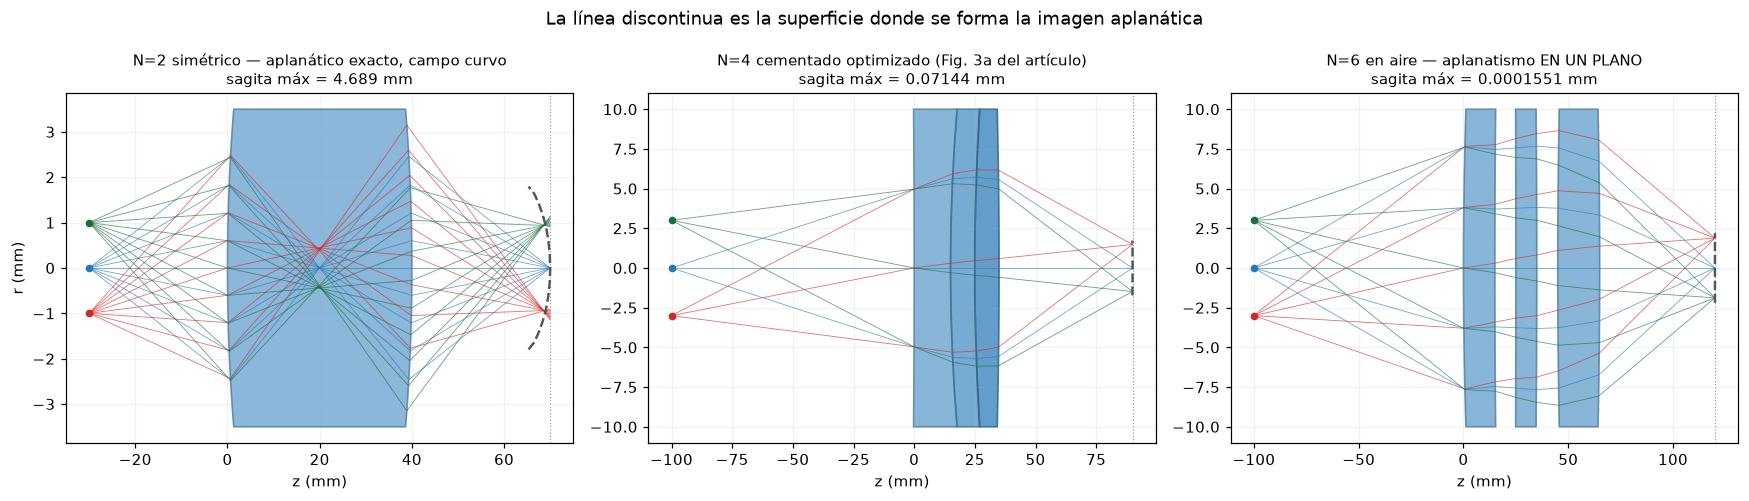

In [7]:
def draw_train(ax, train, fields, na, title, locus_heights):
    # cuerpos de lente automáticos, coloreados por densidad del medio
    draw_system(ax, train, fields=fields, na=na, rays=9)
    locus = aplanatic_image_surface(train, locus_heights, na_object_sine=na)
    pts = locus.points[locus.valid]
    both = np.vstack([pts, pts * np.array([1.0, -1.0, 1.0])])
    order = np.argsort(both[:, 1])
    ax.plot(both[order, 2], both[order, 1], "--", color="#555555", lw=1.6, zorder=4)
    ax.set_title(f"{title}\nsagita máx = {locus.max_sagitta:.4g} mm", fontsize=10)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
draw_train(axes[0], aplanat, [-1.0, 0.0, 1.0], NA,
           "N=2 simétrico — aplanático exacto, campo curvo", np.linspace(0, 2.2, 8))
draw_train(axes[1], cemented, [-3.0, 0.0, 3.0], 0.195,
           "N=4 cementado optimizado (Fig. 3a del artículo)", np.linspace(0, 3.5, 8))
draw_train(axes[2], flat, [-3.0, 0.0, 3.0], 0.15,
           "N=6 en aire — aplanatismo EN UN PLANO", np.linspace(0, 3.5, 8))
axes[0].set_ylabel("r (mm)")
fig.suptitle("La línea discontinua es la superficie donde se forma la imagen aplanática")
fig.tight_layout()
plt.show()

## 5. Mallas de distorsión de los sistemas nuevos

Distorsión por rayo principal (diafragma en el vértice frontal, `stop_index=0`),
malla ideal discontinua contra malla trazada, cada panel con su propio dial de
exageración y la magnitud verdadera en el título. El aplanatismo dice *nada* sobre la
distorsión — y el singlete simétrico lo demuestra: 7 % de corsé, visible a escala
real. El triplete de campo plano la deja en 0,002 %.

N=2 singlete simétrico     cobertura 100.0%   máx   121.689 µm = 7.1706 %


N=4 triplete cementado     cobertura 100.0%   máx     1.778 µm = 0.0848 %


N=6 campo plano            cobertura 100.0%   máx     0.052 µm = 0.0019 %


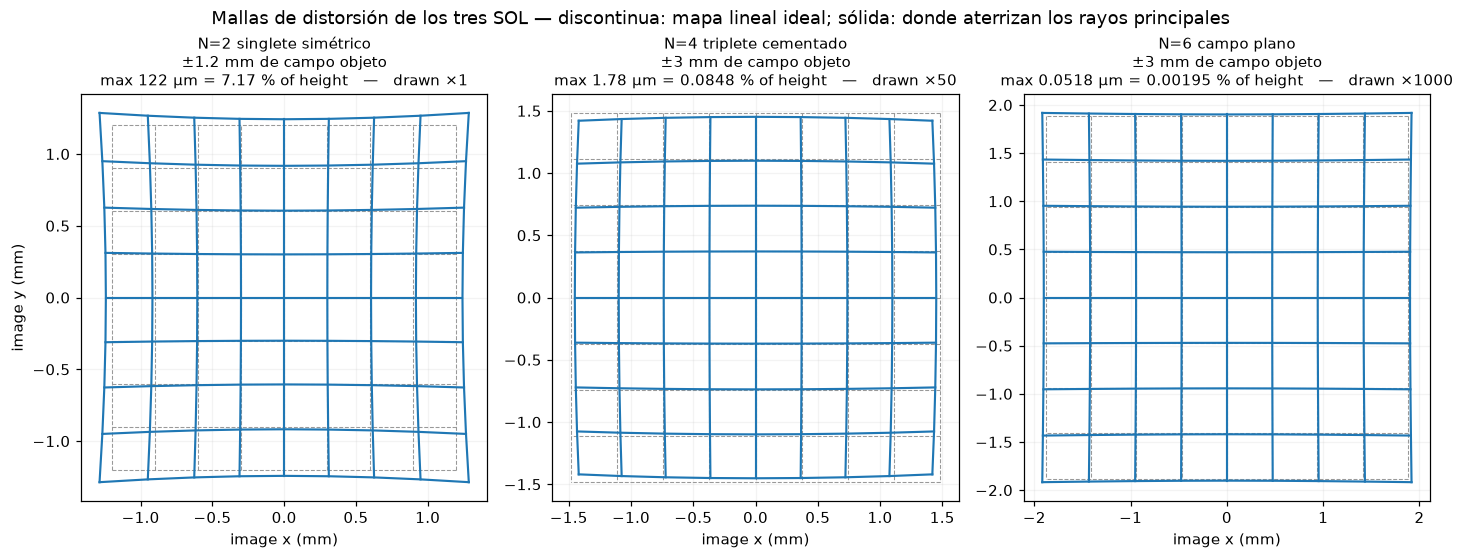

In [8]:
grids, titles, exaggerations = [], [], []
for train, title, half, exaggeration, na in [
    (aplanat,  "N=2 singlete simétrico\n±1.2 mm de campo objeto",  1.2,    1.0, NA),
    (cemented, "N=4 triplete cementado\n±3 mm de campo objeto",    3.0,   50.0, 0.195),
    (flat,     "N=6 campo plano\n±3 mm de campo objeto",           3.0, 1000.0, 0.15),
]:
    tracer = SequentialTracer(train.to_system())
    grid = distortion_grid(tracer, magnification=train.gt, half_field=half,
                           n=9, stop_index=0)
    print(f"{title.splitlines()[0]:26s} cobertura {grid.valid_fraction:5.1%}   "
          f"máx {grid.max_distortion_um:9.3f} µm = {grid.max_relative_distortion_percent:.4f} %")
    grids.append(grid); titles.append(title); exaggerations.append(exaggeration)

fig = plots.distortion_grids_figure(
    grids, titles=titles, exaggerations=exaggerations,
    suptitle="Mallas de distorsión de los tres SOL — discontinua: mapa lineal ideal; "
             "sólida: donde aterrizan los rayos principales")
plt.show()

## 6. Otras aberraciones

**Abanicos de rayos** en $h = 0{,}2$ mm, sobre el plano imagen fijo. La firma está en
la *paridad*: el coma del estigmático es par en la pupila (los dos extremos del
abanico caen del mismo lado); el aplanático es impar — desenfoque por curvatura de
campo más astigmatismo, sin componente de coma.

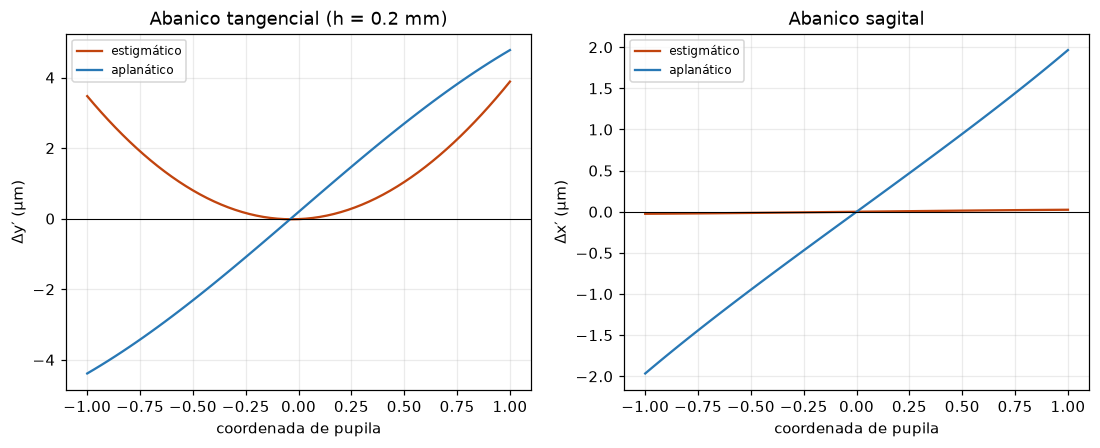

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for name, train, color in [("estigmático", stigmatic, "#c1440e"),
                           ("aplanático", aplanat, "#2878b5")]:
    chief = (0.0 - 0.2) / (0.0 - train.conjugates[0])
    fan = ray_fans(SequentialTracer(train.to_system()), FieldPoint(y=0.2),
                   na_object_sine=NA, magnification=train.gt, chief_slope=chief, n=61)
    axes[0].plot(fan.tangential[:, 0], fan.tangential[:, 1], color=color, label=name)
    axes[1].plot(fan.sagittal[:, 0], fan.sagittal[:, 1], color=color, label=name)
axes[0].set(title="Abanico tangencial (h = 0.2 mm)", xlabel="coordenada de pupila",
            ylabel="Δy′ (µm)")
axes[1].set(title="Abanico sagital", xlabel="coordenada de pupila", ylabel="Δx′ (µm)")
for ax in axes:
    ax.axhline(0, color="black", lw=0.7); ax.grid(alpha=0.25); ax.legend(fontsize=8)
plt.show()

**Métricas de campo** del triplete N=6 de campo plano: spot RMS, distorsión,
curvatura de campo y astigmatismo contra la altura de imagen.

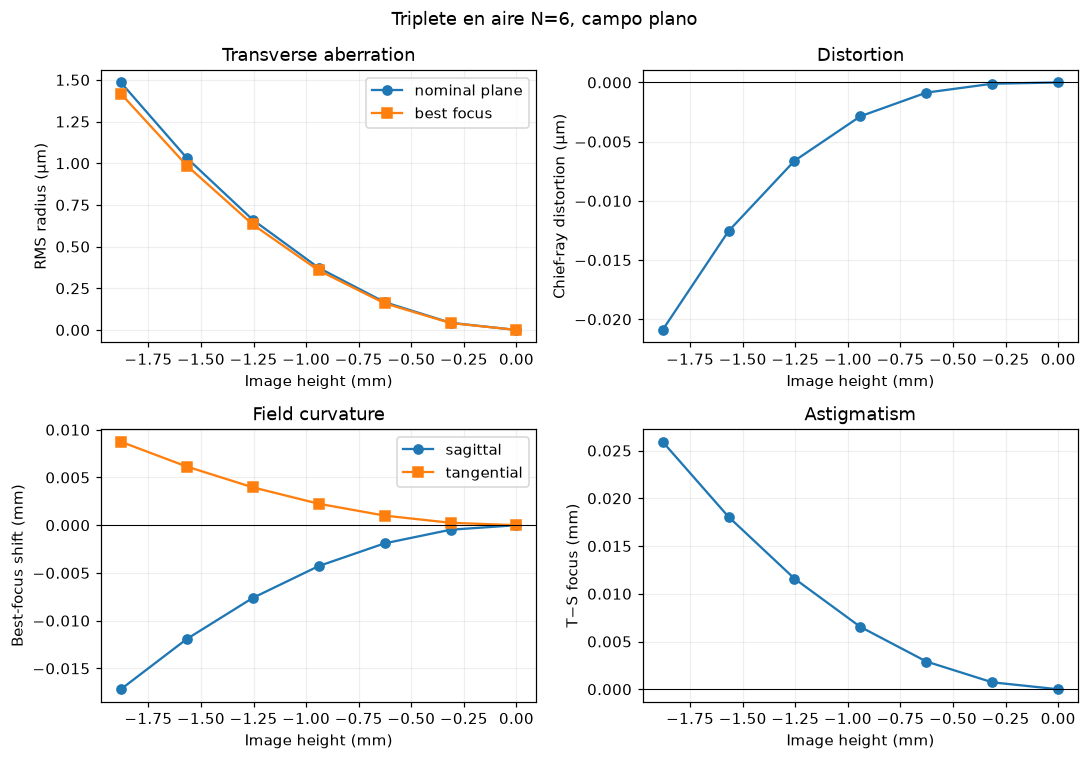

en h = 3 mm:  RMS 1.485 µm   distorsión -0.0209 µm   corrimiento de mejor foco -0.00423 mm


In [10]:
rows = field_metrics(SequentialTracer(flat.to_system()), np.linspace(0.0, 3.0, 7),
                     na_object_sine=0.15, magnification=flat.gt, stop_index=0)
fig = plots.aberrations_figure(rows, suptitle="Triplete en aire N=6, campo plano")
plt.show()
worst = rows[-1]
print(f"en h = 3 mm:  RMS {worst['rms_spot_radius_um']:.3f} µm   "
      f"distorsión {worst['chief_ray_distortion_um']:+.4f} µm   "
      f"corrimiento de mejor foco {worst['best_focus_shift_mm']:+.5f} mm")

**Coeficientes de Seidel** de los tres singletes, ajustados del frente de onda
reconstruido por aberraciones transversales (relación de Hamilton), en ondas a
587,6 nm. La esférica ($S_I$) distingue a la esfera de los trenes de Descartes; el
coma ($S_{II}$) distingue al estigmático del aplanático.

In [11]:
print(f"{'sistema':14s} {'S_I esférica (ondas)':>22s} {'S_II coma (ondas/mm)':>22s} "
      f"{'astig (ondas/mm²)':>19s}")
for name, system in [("esfera", sphere), ("estigmático", stigmatic.to_system()),
                     ("aplanático", aplanat.to_system())]:
    s = seidel_coefficients(SequentialTracer(system), [0.0, 0.14, 0.2],
                            na_object_sine=NA, na_image=NA,
                            wavelength_mm=5.876e-4, stop_index=0)
    print(f"{name:14s} {s.spherical_coefficient:+22.4f} {s.coma_coefficient:+22.4f} "
          f"{s.astigmatism_coefficient:+19.4f}")

sistema          S_I esférica (ondas)   S_II coma (ondas/mm)   astig (ondas/mm²)
esfera                       -22.7602               -18.5504             +4.8045
estigmático                   -0.0007                -1.1035             -0.1915
aplanático                    +0.0039                -0.0174             +2.5719


La esférica ajustada de la esfera es −22,8 ondas — y es una *subestimación*: su
frente de onda real lleva miles de ondas y el ajuste de bajo orden satura; aún así
queda cuatro órdenes por encima del residuo (~10⁻³ ondas) de los dos trenes de
Descartes. El coma del estigmático (−1,1 ondas/mm) cae ~60× en el aplanático, cuyo
término dominante pasa a ser el cuadrático en campo — astigmatismo y curvatura —
exactamente lo que el experimento de campo plano de la sección 4 corrige con más
superficies.

---

El guion ejecutable de esta comparación es
`python -m examples.stigmatic_surfaces.aplanatic_sol`; la construcción (`StigmaticTrain`),
el análisis (`raytracer.analysis.aberrations.aplanatism`) y el optimizador
(`raytracer.optimize`) están descritos en el README, sección *Lentes estigmáticas y
aplanatismo*.